In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LogisticRegression

In [4]:
df = pd.read_csv('data-week-3.csv')
df.columns = df.columns.str.lower().str.replace(' ','_')
categorical_cols = list(df.dtypes[df.dtypes == 'object'].index)
categorical_cols += list(df.dtypes[df.dtypes == 'str'].index)

for c in categorical_cols:
    df[c] = df[c].str.lower().str.replace(' ','_')
df.totalcharges = pd.to_numeric(df.totalcharges, errors='coerce')
df.totalcharges = df.totalcharges.fillna(0)

df.churn = (df.churn=='yes').astype(int)

In [5]:
df_full_train, df_test = train_test_split(df, test_size = 0.2, random_state = 42)
df_train, df_val = train_test_split(df_full_train, test_size = 0.25, random_state = 42)

df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

y_train = df_train.churn
y_val = df_val.churn
y_test = df_test.churn

del df_train['churn']
del df_val['churn']
del df_test['churn']

In [6]:
num_f = ['tenure', 'monthlycharges', 'totalcharges']
cat_f = ['gender',
    'seniorcitizen',
    'partner',
    'dependents',
    'phoneservice',
    'multiplelines',
    'internetservice',
    'onlinesecurity',
    'onlinebackup',
    'deviceprotection',
    'techsupport',
    'streamingtv',
    'streamingmovies',
    'contract',
    'paperlessbilling',
    'paymentmethod',]

In [7]:
def train(df_train, y_train, C=1.0):

    X_train_num = df_train[num_f].values
    scaler = StandardScaler()
    X_train_num = scaler.fit_transform(X_train_num)

    ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

    X_train_cat = df_train[cat_f].values

    X_train_cat = ohe.fit_transform(X_train_cat)

    X_train = np.column_stack([X_train_num, X_train_cat])

    model = LogisticRegression(C=C, max_iter=1000)
    model.fit(X_train, y_train)

    return scaler, ohe, model

In [8]:
scaler,ohe, model = train(df_full_train, df_full_train.churn.values, C=1.0)

# Saving and loading the model

In [11]:
import pickle
C = 1.0

In [13]:
output_file = f'model_C={C}.bin'
with open(output_file, 'wb') as f_out:
    pickle.dump((scaler, ohe, model), f_out)

# Loading the model

In [14]:
with open('model_C=1.0.bin', 'rb') as f_in:
    scaler, ohe, model = pickle.load(f_in)

# Web services: intro to Flask

In [15]:
from flask import Flask

In [ ]:
app = Flask('ping')

@app.route('/ping', methods=['GET'])
def ping():
    return "PONG"

app.run(debug=True, host='0.0.0.0', port=5000)

# Serving the churn model with Flask

In [20]:
!python predict.py

 * Serving Flask app 'churn'
 * Debug mode: on
Address already in use
Port 9696 is in use by another program. Either identify and stop that program, or start the server with a different port.


In [21]:
!python predict-test.py

Status: 200
Body: '{\n  "churn": false,\n  "churn_probability": 0.38622711639830326\n}\n'
not sending promo email to xyz-123


# Running in production: gunicorn

A WSGI server is the production replacement. WSGI (Web Server Gateway Interface) is the standard way python web app are served: the WSGI server imports the app object and handles all the network work

In [22]:
!gunicorn --bind=0.0.0.0:9696 predict:app

[2026-09-11 14:25:21 +0200] [36692] [INFO] Starting gunicorn 26.2.0
[2026-09-11 14:25:21 +0200] [36692] [INFO] Listening at: http://0.0.0.0:9696 (36692)
[2026-09-11 14:25:21 +0200] [36692] [INFO] Using worker: sync
[2026-09-11 14:25:21 +0200] [36693] [INFO] Booting worker with pid: 36693
[2026-09-11 14:25:21 +0200] [36692] [INFO] Control socket listening at /run/user/1000/gunicorn.ctl
^C
[2026-09-11 14:27:24 +0200] [36692] [INFO] Handling signal: int
[2026-09-11 14:27:24 +0200] [36693] [INFO] Worker exiting (pid: 36693)


In [23]:
!uv run gunicorn --bind=0.0.0.0:9696 predict:app

[2026-09-11 14:27:32 +0200] [36880] [INFO] Starting gunicorn 26.2.0
[2026-09-11 14:27:32 +0200] [36880] [INFO] Listening at: http://0.0.0.0:9696 (36880)
[2026-09-11 14:27:32 +0200] [36880] [INFO] Using worker: sync
[2026-09-11 14:27:32 +0200] [36881] [INFO] Booting worker with pid: 36881
[2026-09-11 14:27:32 +0200] [36880] [INFO] Control socket listening at /run/user/1000/gunicorn.ctl
^C
[2026-09-11 14:39:46 +0200] [36880] [INFO] Handling signal: int
[2026-09-11 14:39:46 +0200] [36881] [INFO] Worker exiting (pid: 36881)


# Environment management: Docker(podman)

Env isolates the packages of a project, but the rest of the environment is still shared. A service that works on a laptop may fail on a server.
Docker solves this by packing the app together with its whole environment into an image. A container started from that image behaves identically on any machine running Docker.

In [24]:
#podman build -t <tag> .

In [25]:
#podman run -it -p 9696:9696 :

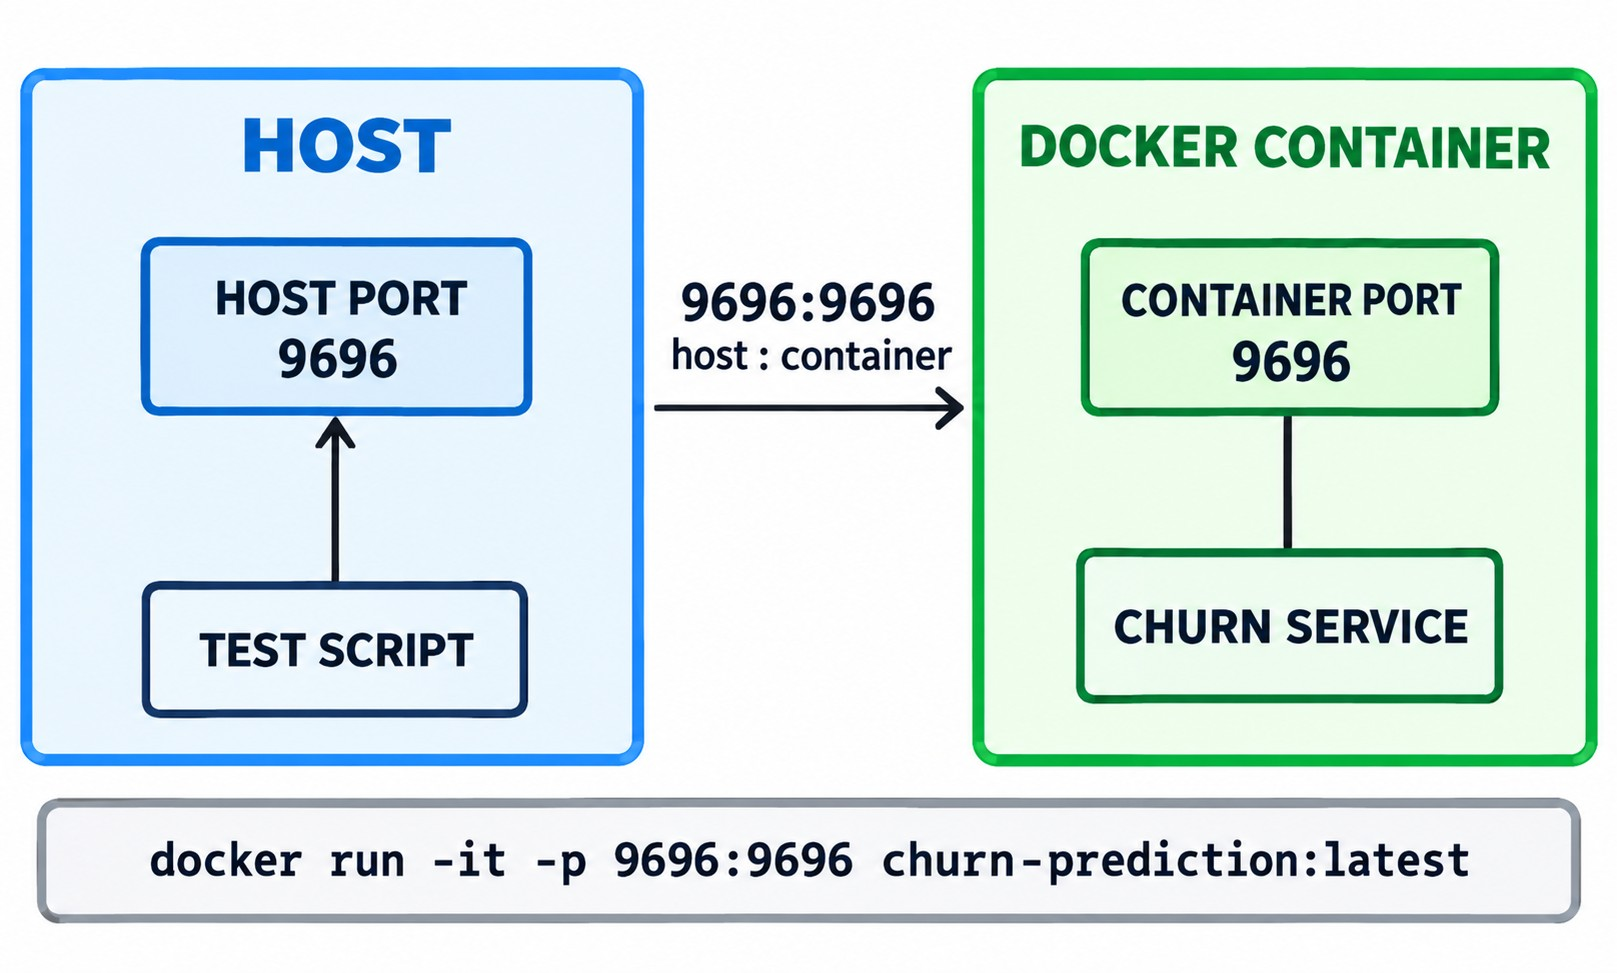

# Deployment to the cloud: AWS Elastic Beanstalk

So far the service runs only on our machine. For marketing service to use it, the model has to run somwhere both can reach, a server in the cloud. A cloud provider gives us virtual machines on demand, and AWS is the most popular. Elastic Beanstalk (EB) is AWS's simple deployment service: we give it our application, and it takes care of the rest. It starts the instances, keeps the app running and scales it.

## Deploying step by step

First we need EB cli. we install it as dev dependency.